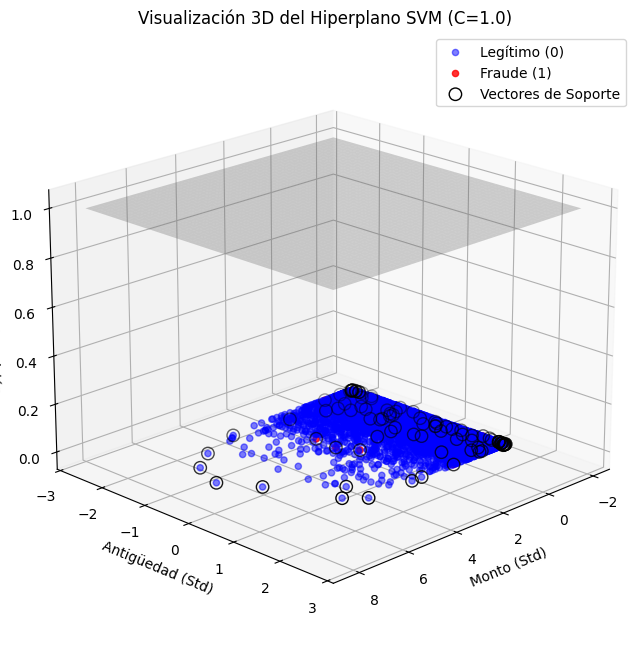

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D

# ==========================================
# 1. Preparación de Datos
# ==========================================
df = pd.read_csv('fraude.csv')
X = df[['monto', 'antiguedad_cuenta']].values
y = df['es_fraude'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Entrenamos el modelo
C_value = 1.0
svm_model = SVC(kernel='linear', C=C_value)
svm_model.fit(X_scaled, y)

# ==========================================
# 2. Configuración de la Visualización 3D
# ==========================================
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Creamos una malla para el "suelo" (X e Y)
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50),
                     np.linspace(y_min, y_max, 50))

# Calculamos el valor de Z (Función de decisión)
# La ecuación del hiperplano es: w0*x + w1*y + b = 0
w = svm_model.coef_[0]
b = svm_model.intercept_[0]
zz = (-w[0] * xx - w[1] * yy - b)

# --- Graficar Elementos ---

# 1. El Hiperplano de decisión (donde Z = 0 en el contexto de los datos)
# Nota: Aquí graficamos el plano inclinado que separa las clases
ax.plot_surface(xx, yy, zz, alpha=0.3, color='gray', antialiased=True)

# 2. Los puntos de datos
# Clase 0 (Legítimo)
ax.scatter(X_scaled[y == 0, 0], X_scaled[y == 0, 1], 0,
           color='blue', label='Legítimo (0)', alpha=0.5, s=20)
# Clase 1 (Fraude)
ax.scatter(X_scaled[y == 1, 0], X_scaled[y == 1, 1], 0,
           color='red', label='Fraude (1)', alpha=0.8, s=20)

# 3. Vectores de Soporte (proyectados en el suelo)
ax.scatter(svm_model.support_vectors_[:, 0], svm_model.support_vectors_[:, 1], 0,
           s=80, facecolors='none', edgecolors='black', label='Vectores de Soporte')

# Configuración de etiquetas
ax.set_xlabel('Monto (Std)')
ax.set_ylabel('Antigüedad (Std)')
ax.set_zlabel('Margen / Decisión')
ax.set_title(f'Visualización 3D del Hiperplano SVM (C={C_value})')
ax.view_init(elev=20, azim=45) # Cambia estos ángulos para rotar la cámara
plt.legend()
plt.show()